# 01 · Data exploration — NASA C-MAPSS FD001

**Goal:** understand the data before modelling: structure, quality, which sensors carry a degradation signal, how balanced the label is and where leakage could appear.

**Rules for this notebook:** it only *explores*. Reusable logic lives in `src/industrial_ai/` and decisions are recorded in `docs/ml.md`.

**Data:** NASA C-MAPSS turbofan degradation simulation (Saxena & Goebel, 2008), used as a proxy for the gas-generator core of the fictitious aeroderivative units GT-101/GT-102. Download it first with `python scripts/download_data.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split

from industrial_ai.ml.data import (
    SENSOR_COLUMNS,
    SENSOR_DESCRIPTIONS,
    SETTING_COLUMNS,
    load_rul,
    load_trajectories,
)
from industrial_ai.ml.labels import LABEL_COLUMN, add_failure_label, add_rul_test, add_rul_train

pd.set_option("display.max_columns", 40)
SUBSET = "FD001"
HORIZON = 30

## 1. Load and validate

The loaders raise an error if a file does not have the expected structure (26 columns, no missing values, contiguous cycles starting at 1 in every unit). Getting here without errors is already a data-quality check.

In [2]:
train = add_rul_train(load_trajectories(SUBSET, "train"))
test = add_rul_test(load_trajectories(SUBSET, "test"), load_rul(SUBSET))

print(f"train: {len(train):,} rows · {train['unit'].nunique()} units")
print(f"test:  {len(test):,} rows · {test['unit'].nunique()} units")
train.head()

train: 20,631 rows · 100 units
test:  13,096 rows · 100 units


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


## 2. Lifetimes of the training units

Every training unit runs until failure, so its number of cycles is its lifetime.
**Think about:** how much do lifetimes vary? Why does that matter when we use a fixed horizon of 30 cycles?

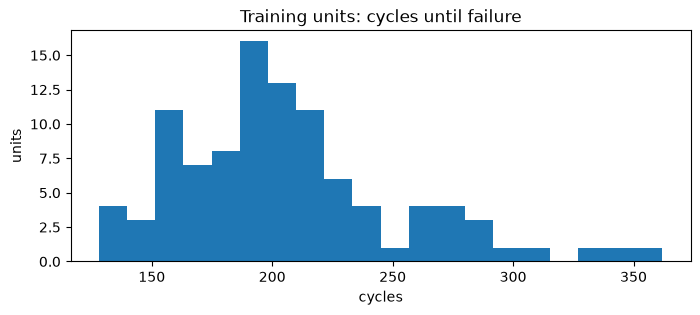

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

In [3]:
lifetimes = train.groupby("unit")["cycle"].max()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lifetimes, bins=20)
ax.set(title="Training units: cycles until failure", xlabel="cycles", ylabel="units")
plt.show()

lifetimes.describe()

## 3. Data quality: missing values and uninformative columns

A column that barely changes cannot carry information about degradation. We look at the number of distinct values and the standard deviation of every setting and sensor.
**Write down** which columns look constant or near-constant; the decision to drop them is made in block 1.2 and recorded in `docs/ml.md`.

In [4]:
measurement_columns = SETTING_COLUMNS + SENSOR_COLUMNS
quality = pd.DataFrame(
    {
        "missing": train[measurement_columns].isna().sum(),
        "n_unique": train[measurement_columns].nunique(),
        "std": train[measurement_columns].std(),
    }
)
quality["description"] = quality.index.map(SENSOR_DESCRIPTIONS)
quality.sort_values("std")

,missing,n_unique,std,description
sensor_1,0,1,0.000000e+00,T2 - total temperature at fan inlet (°R)
setting_3,0,1,0.000000e+00,NaN
sensor_10,0,1,0.000000e+00,epr - engine pressure ratio (P50/P2)
sensor_19,0,1,0.000000e+00,PCNfR_dmd - demanded corrected fan speed (rpm)
sensor_18,0,1,0.000000e+00,Nf_dmd - demanded fan speed (rpm)
sensor_16,0,1,3.469531e-18,farB - burner fuel-air ratio
sensor_5,0,1,5.329200e-15,P2 - pressure at fan inlet (psia)
setting_2,0,13,2.930621e-04,NaN
sensor_6,0,2,1.388985e-03,P15 - total pressure in bypass duct (psia)
setting_1,0,158,2.187313e-03,NaN


## 4. Operating conditions

FD001 is documented as a single operating condition, so the three settings should only show small variations. If they varied a lot, sensors would have to be normalised per operating regime (that is the case in FD002 and FD004).

In [5]:
train[SETTING_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000


## 5. Degradation signal: sensors aligned by remaining useful life

Plotting against cycle mixes units with very different lifetimes. Aligning every unit by its **RUL** (failure on the right) shows whether a sensor drifts as failure approaches.

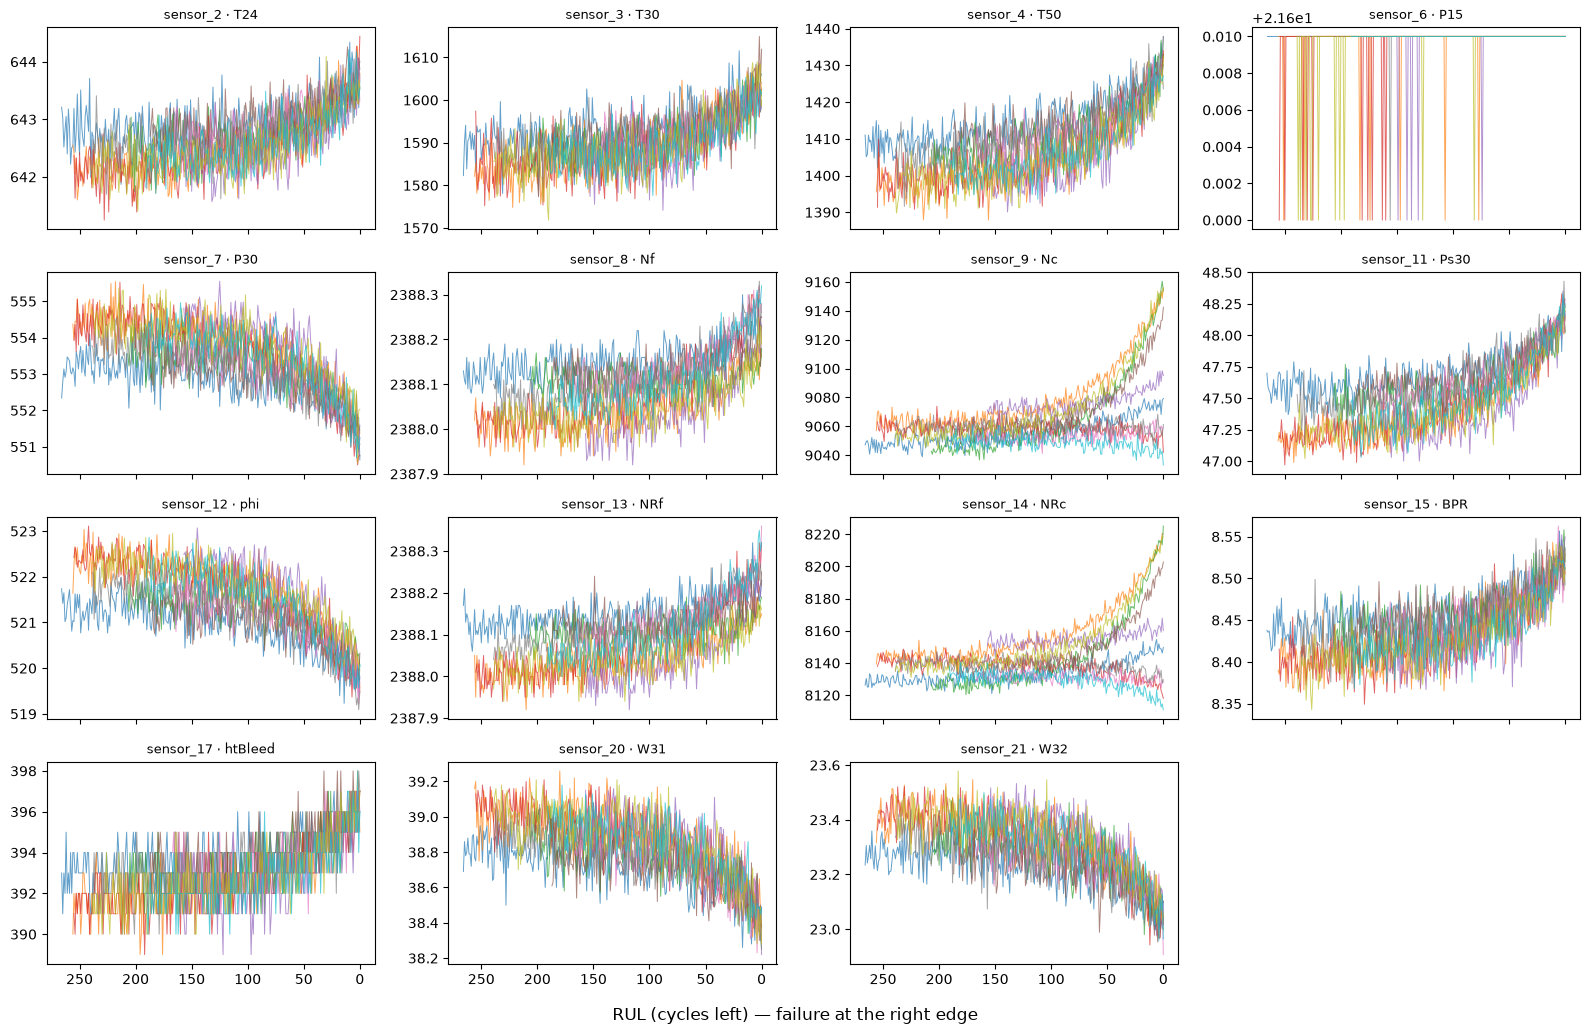

In [6]:
candidates = [column for column in SENSOR_COLUMNS if train[column].nunique() > 1]
sample_units = train["unit"].drop_duplicates().sample(10, random_state=42)

n_cols = 4
n_rows = int(np.ceil(len(candidates) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.6 * n_rows), sharex=True)
for ax, sensor in zip(axes.flat, candidates, strict=False):
    for unit in sample_units:
        unit_data = train[train["unit"] == unit]
        ax.plot(unit_data["rul"], unit_data[sensor], linewidth=0.7, alpha=0.7)
    short_name = SENSOR_DESCRIPTIONS[sensor].split(" - ")[0]
    ax.set_title(f"{sensor} · {short_name}", fontsize=9)
for ax in axes.flat[len(candidates) :]:
    ax.set_visible(False)
axes.flat[0].invert_xaxis()  # shared x axis: inverting once flips every panel
fig.supxlabel("RUL (cycles left) — failure at the right edge")
fig.tight_layout()
plt.show()

## 6. Monotonic association with RUL

Spearman correlation measures whether a sensor tends to go up (or down) as RUL decreases, without assuming a linear relationship.

Two cautions for the interview:
- **Correlation is not causation.** A sensor can correlate with RUL because it reacts to the same underlying degradation, not because it causes it.
- These correlations pool all units, so they mix *within-unit* degradation with *between-unit* differences.

In [7]:
correlation_with_rul = (
    train[candidates + ["rul"]]
    .corr(method="spearman")["rul"]
    .drop("rul")
    .sort_values(key=np.abs, ascending=False)
)
correlation_with_rul.to_frame("spearman_vs_rul").assign(
    description=lambda df: df.index.map(SENSOR_DESCRIPTIONS)
)

,spearman_vs_rul,description
sensor_11,-0.718132,Ps30 - static pressure at HPC outlet (psia)
sensor_4,-0.701771,T50 - total temperature at LPT outlet (°R)
sensor_12,0.693149,phi - ratio of fuel flow to Ps30 (pps/psi)
sensor_7,0.678845,P30 - total pressure at HPC outlet (psia)
sensor_15,-0.665905,BPR - bypass ratio
sensor_21,0.657417,W32 - LPT coolant bleed (lbm/s)
sensor_20,0.653336,W31 - HPT coolant bleed (lbm/s)
sensor_17,-0.629397,htBleed - bleed enthalpy
sensor_2,-0.628588,T24 - total temperature at LPC outlet (°R)
sensor_3,-0.605609,T30 - total temperature at HPC outlet (°R)


## 7. Label balance

Positive label = the unit fails within the next `HORIZON` cycles (RUL ≤ horizon). The horizon is a business choice: how much warning does maintenance need to plan an intervention? We compare a few values to see how it changes the class balance.

In [8]:
balance = pd.DataFrame(
    {
        horizon: add_failure_label(train, horizon)[LABEL_COLUMN].value_counts(normalize=True)
        for horizon in (15, 30, 50)
    }
).T.rename(columns={0: "negative", 1: "positive"})
balance.index.name = "horizon"
balance.round(3)

failure_within_horizon,negative,positive
horizon,,
15,0.922,0.078
30,0.850,0.150
50,0.753,0.247


## 8. Test set: truncated trajectories

Test units stop **before** failure. The RUL file gives the true remaining life after the last observed cycle, from which the RUL of every earlier cycle is reconstructed. Because trajectories are truncated, the positive rate in the test set is expected to differ from training.

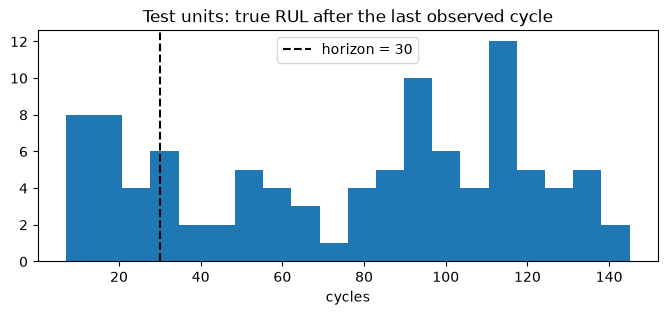

positive rate in test (all cycles): 0.025


,observed_cycles,rul_at_last_cycle
count,100.000000,100.00000
mean,130.960000,75.52000
std,53.593479,41.76497
min,31.000000,7.00000
25%,88.750000,32.75000
50%,133.500000,86.00000
75%,164.250000,112.25000
max,303.000000,145.00000


In [9]:
test_summary = test.groupby("unit").agg(
    observed_cycles=("cycle", "max"), rul_at_last_cycle=("rul", "min")
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(test_summary["rul_at_last_cycle"], bins=20)
ax.axvline(HORIZON, color="black", linestyle="--", label=f"horizon = {HORIZON}")
ax.set(title="Test units: true RUL after the last observed cycle", xlabel="cycles")
ax.legend()
plt.show()

test_labelled = add_failure_label(test, HORIZON)
print(f"positive rate in test (all cycles): {test_labelled[LABEL_COLUMN].mean():.3f}")
test_summary.describe()

## 9. Leakage risk: random rows vs whole units

Consecutive cycles of the same engine are very similar and share that engine's own baseline. With a **random row split**, the model is evaluated on rows whose neighbours it saw during training. With a **split by unit**, every test engine is completely new, which is the real situation.

Experiment: same model, same raw sensors, two ways of splitting. One split is noisy, so read the gap as an indication; block 1.2 uses grouped cross-validation. If the gap is small here, it usually grows once we add rolling features, because overlapping windows make neighbouring rows share even more information.

In [10]:
labelled = add_failure_label(train, HORIZON)
X = labelled[candidates]
y = labelled[LABEL_COLUMN]
groups = labelled["unit"]


def pr_auc_for_split(train_idx, test_idx):
    model = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=42)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    scores = model.predict_proba(X.iloc[test_idx])[:, 1]
    return average_precision_score(y.iloc[test_idx], scores)


rows = np.arange(len(labelled))
random_train, random_test = train_test_split(rows, test_size=0.2, random_state=42, stratify=y)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
group_train, group_test = next(splitter.split(X, y, groups))

print(f"random row split  PR-AUC: {pr_auc_for_split(random_train, random_test):.3f}")
print(f"split by unit     PR-AUC: {pr_auc_for_split(group_train, group_test):.3f}")
print(f"positive rate (baseline PR-AUC of a random model): {y.mean():.3f}")

random row split  PR-AUC: 0.956
split by unit     PR-AUC: 0.961
positive rate (baseline PR-AUC of a random model): 0.150


## 10. Findings

- **Size:** train 20,631 rows / 100 units; test 13,096 rows / 100 units (both match the published FD001 sizes). Lifetimes of training units: min 128 / median 199 / max 362 cycles (mean 206, std 46), right-skewed with a few long-lived units.
- **Quality:** no missing values. Constant columns (a single distinct value): `setting_3` and sensors 1, 5, 10, 16, 18 and 19; the non-zero std of sensors 5 and 16 is floating-point noise. Near-constant: sensor 6 takes only two values (21.60 / 21.61) and has a weak correlation with RUL (−0.13), so it is quantisation noise. **Kept: 14 sensors** (2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21).
- **Operating conditions:** yes, a single regime. `setting_3` is constant at 100, and `setting_1` (±0.009) and `setting_2` (±0.0006) only show small symmetric noise around 0. The settings carry no information in FD001 and are not used as features.
- **Degradation signal:** as failure approaches, sensors 2 (T24), 3 (T30), 4 (T50), 8 (Nf), 11 (Ps30), 13 (NRf), 15 (BPR) and 17 (htBleed) increase, and sensors 7 (P30), 12 (phi), 20 (W31) and 21 (W32) decrease. Strongest Spearman correlations with RUL: sensor 11 (−0.72), 4 (−0.70), 12 (+0.69), 7 (+0.68) and 15 (−0.67); a negative sign means the sensor rises as RUL falls. Sensors 9 (Nc) and 14 (NRc) change clearly within each unit but in opposite directions depending on the unit, hence their weak pooled correlation (−0.32 / −0.20). Cycle-to-cycle noise dominates until roughly the last 50–100 cycles, and units start at visibly different levels. Physical and corrected speeds (8/13 and 9/14) are nearly redundant under a single operating condition.
- **Label balance:** at H = 30, 15.0% of training cycles are positive (7.8% at H = 15, 24.7% at H = 50). In the test set only 2.5% of all cycles are positive, because trajectories are truncated and most units end far from failure (median true RUL after the last cycle: 86, range 7–145). This prevalence shift means precision and PR-AUC will not be comparable between cross-validation and test, while recall will.
- **Leakage experiment:** PR-AUC 0.956 with a random row split vs 0.961 with a split by unit (single split, random forest on raw sensors; a random model would score 0.150). There is no measurable gap. Likely reason: each raw reading carries independent noise, and the degradation signature is shared by the whole fleet (one fault mode), so the model learns a fleet-wide pattern rather than memorising units. The split by unit is kept anyway because it reproduces deployment (the model is always evaluated on unseen engines). One split is noisy, so this is an indication, not a conclusion.
- **Open questions:**
  - Will the leakage gap appear with rolling features, where neighbouring rows share overlapping windows? (to be tested with grouped vs random 5-fold CV)
  - Do sensors 9 and 14 add information despite their inconsistent direction across units?
  - Does comparing each unit with its own early-life baseline remove the unit-to-unit offsets?
  - Should the unit's age (`cycle`) be a feature, or would it teach "old units fail" instead of health?
  - How should the test set be evaluated given its 2.5% prevalence: every cycle, last cycle per unit, or both?